In [14]:
# compile results
import pickle

homedir = "/home/annzhou/"
load_list = [20,40,60]
sumfile = "fct_summary.txt"
datadict = dict()
with open(sumfile,'w') as fw:
    for i in ["unv1"]:
        for j in ["dring","leafspine"]:
            for load in load_list:
                outfile = f"outfiles/{i}_{j}_load{load}.out"
                durationlist = list()
                sizelist = list()
                startlist = list()
                with open(outfile,'r') as fr:
                    lines = fr.readlines()
                    for line in lines:
                        tokens = line.split()
                        if tokens[0] == "FCT":
                            durationlist.append(float(tokens[2]))
                            sizelist.append(int(tokens[1]))
                            startlist.append(float(tokens[3]))
                durationlist.sort()
                datadict[outfile] = [durationlist,sizelist,startlist]
                
                fw.write(f"{outfile}\t{sum(durationlist)/len(durationlist)}\t{durationlist[int(len(durationlist)*0.5)]}\t{durationlist[int(len(durationlist)*0.99)]}\t{durationlist[int(len(durationlist)*0.9999)]}\n")

with open(f'{homedir}nsdi26fall_pickle/test_general_setup.pickle', 'wb') as handle:
    pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
homedir = "/home/annzhou/"
with open(f'{homedir}nsdi26fall_pickle/test_general_setup.pickle', "rb") as f:
    datadict = pickle.load(f)

outfiles/unv1_dring_load20.out 97p 4.45654 avg_last10p 6.457331861572272
outfiles/unv1_dring_load40.out 97p 2.3719 avg_last10p 5.392719660292967
outfiles/unv1_dring_load60.out 97p 7.31751 avg_last10p 6.529401986930903
outfiles/unv1_leafspine_load20.out 97p 1.18181 avg_last10p 3.660979780863488
outfiles/unv1_leafspine_load40.out 97p 2.2874 avg_last10p 4.7585034265966835
outfiles/unv1_leafspine_load60.out 97p 9.73675 avg_last10p 6.39267646749708


/home/annzhou/DRing/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


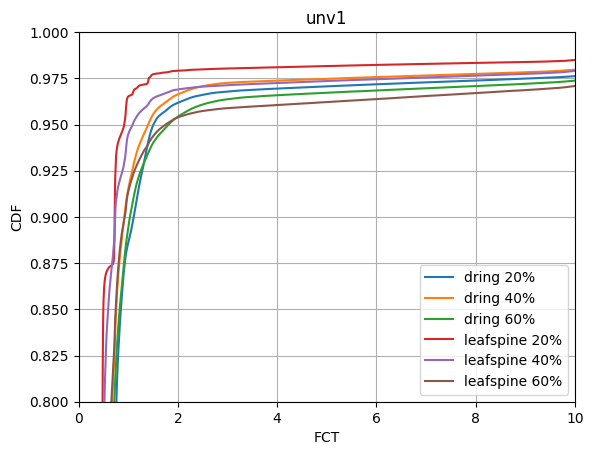

In [18]:
# draft plot results
import matplotlib.pyplot as plt
import numpy as np

for j in ["dring","leafspine"]:
    tailfct_list = list()
    for load in load_list:
        outfile = f"outfiles/{i}_{j}_load{load}.out"
        durationlist = datadict[outfile][0]
        print(f"{outfile} 97p {durationlist[int(len(durationlist)*0.97)]} avg_last10p {np.array(durationlist[int(len(durationlist)*0.9):]).mean()}")
        cdf = np.arange(1, len(durationlist)+1) / len(durationlist)
        plt.plot(durationlist, cdf, label=f"{j} {load}%")
plt.xlim(0,10)
plt.ylim(0.8,1)
plt.xlabel("FCT")
plt.ylabel("CDF")
plt.title("unv1")
plt.grid(True)
plt.legend()
plt.show()